In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/1429_1.csv"
data = pd.read_csv(path)

data.head()

/tmp/ipykernel_9473/4006459749.py:4: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [ ]:
data.columns

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='object')

In [ ]:
reviews = data['reviews.text'].dropna().head(1000)

print(reviews.head(10))
print("Total reviews:", len(reviews))

0    This product so far has not disappointed. My c...
1    great for beginner or experienced person. Boug...
2    Inexpensive tablet for him to use and learn on...
3    I've had my Fire HD 8 two weeks now and I love...
4    I bought this for my grand daughter when she c...
5    This amazon fire 8 inch tablet is the perfect ...
6    Great for e-reading on the go, nice and light ...
7    I gave this as a Christmas gift to my inlaws, ...
8    Great as a device to read books. I like that i...
9    I love ordering books and reading them with th...
Name: reviews.text, dtype: object
Total reviews: 1000


In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

sentiment = reviews.apply(get_sentiment)

print(sentiment.value_counts())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


reviews.text
Positive    906
Negative     62
Neutral      32
Name: count, dtype: int64


In [ ]:
aspects = ['price', 'battery', 'screen', 'quality', 'performance']
def get_aspect_reviews(reviews, aspect):
    return reviews[reviews.str.contains(aspect, case=False, na=False)]

In [ ]:
results = {}

for aspect in aspects:
    aspect_data = get_aspect_reviews(reviews, aspect)
    aspect_sentiment = aspect_data.apply(get_sentiment)
    results[aspect] = aspect_sentiment.value_counts()

results

{'price': reviews.text
 Positive    179
 Negative      9
 Neutral       5
 Name: count, dtype: int64,
 'battery': reviews.text
 Positive    42
 Negative     4
 Neutral      2
 Name: count, dtype: int64,
 'screen': reviews.text
 Positive    114
 Negative     10
 Neutral       3
 Name: count, dtype: int64,
 'quality': reviews.text
 Positive    44
 Negative     1
 Name: count, dtype: int64,
 'performance': reviews.text
 Positive    13
 Negative     2
 Name: count, dtype: int64}

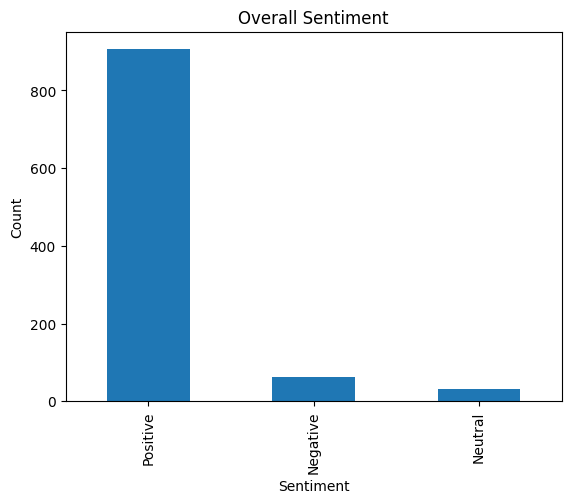

In [ ]:
import matplotlib.pyplot as plt

sentiment.value_counts().plot(kind='bar')
plt.title("Overall Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

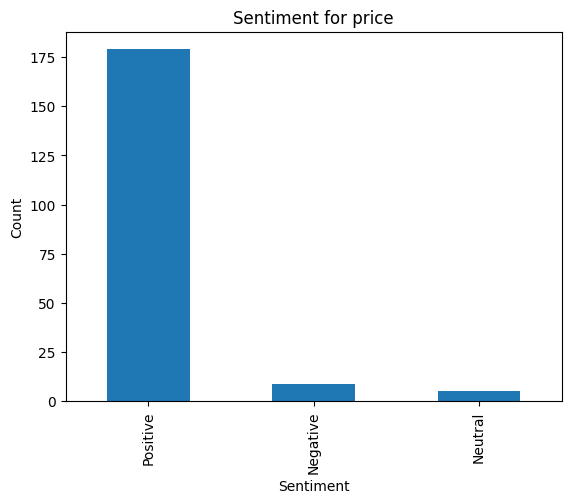

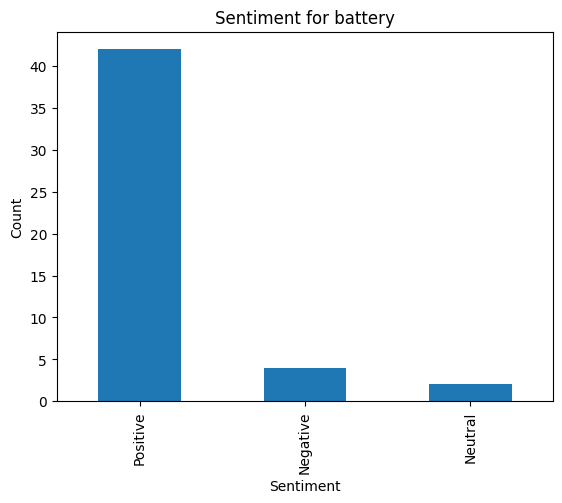

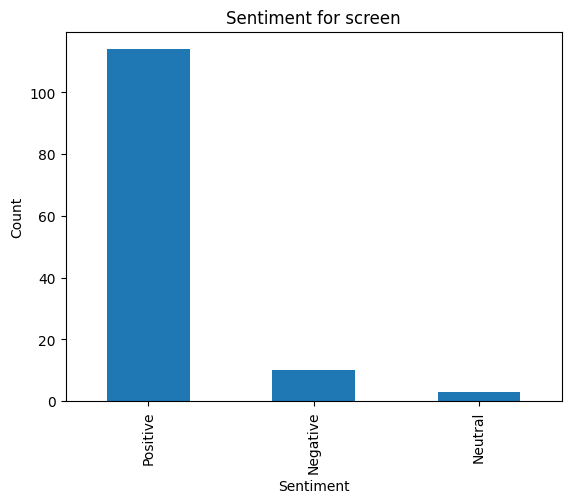

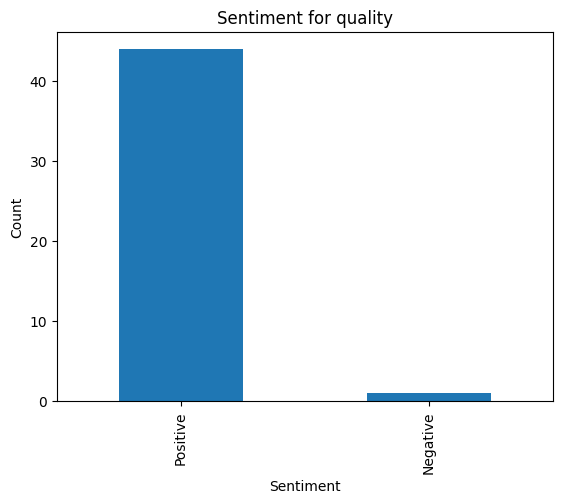

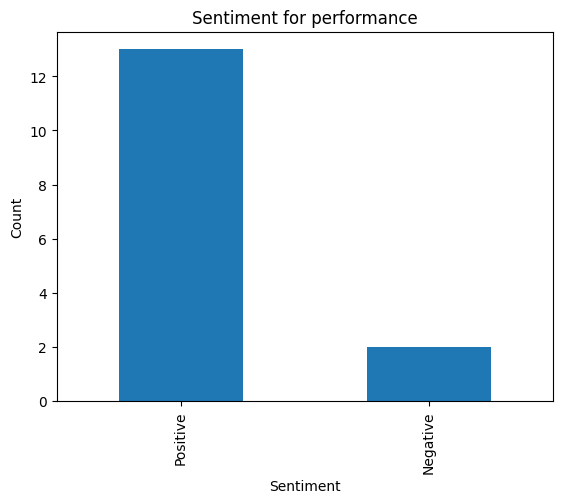

In [ ]:
zfor aspect, data in results.items():
    data.plot(kind='bar')
    plt.title(f"Sentiment for {aspect}")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results).fillna(0)
print(df_results)

              price  battery  screen  quality  performance
reviews.text                                              
Negative          9        4      10      1.0          2.0
Neutral           5        2       3      0.0          0.0
Positive        179       42     114     44.0         13.0


In [ ]:
sample_reviews = reviews.head(10).reset_index(drop=True)
print(sample_reviews)
y_true = [
    "Positive",
    "Positive",
    "Positive",
    "Neutral",
    "Positive",
    "Positive",
    "Positive",
    "Neutral",
    "Positive",
    "Positive"
]
y_pred = sample_reviews.apply(get_sentiment).tolist()
print(y_pred)

0    This product so far has not disappointed. My c...
1    great for beginner or experienced person. Boug...
2    Inexpensive tablet for him to use and learn on...
3    I've had my Fire HD 8 two weeks now and I love...
4    I bought this for my grand daughter when she c...
5    This amazon fire 8 inch tablet is the perfect ...
6    Great for e-reading on the go, nice and light ...
7    I gave this as a Christmas gift to my inlaws, ...
8    Great as a device to read books. I like that i...
9    I love ordering books and reading them with th...
Name: reviews.text, dtype: object
['Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive', 'Positive']


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

evaluation_matrix = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})

evaluation_matrix['Score'] = evaluation_matrix['Score'].round(2)

print(evaluation_matrix)


      Metric  Score
0   Accuracy   0.80
1  Precision   0.64
2     Recall   0.80
3   F1-Score   0.71


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Benchmark


          Before  After
Positive     880    906
Negative      75     62
Neutral       45     32


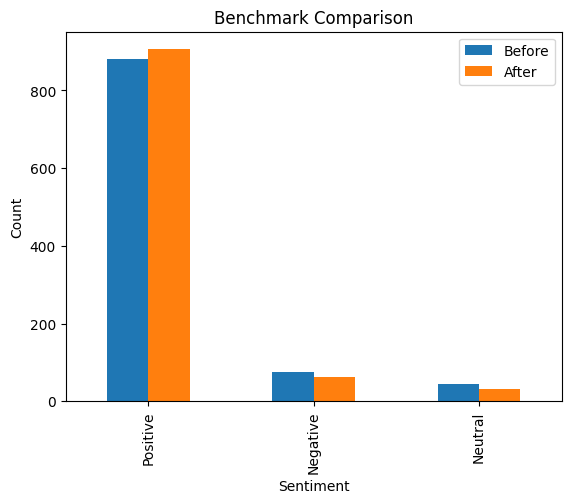

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

before = pd.Series({
    "Positive": 880,
    "Negative": 75,
    "Neutral": 45
})

after = sentiment.value_counts()

benchmark = pd.DataFrame({
    'Before': before,
    'After': after
}).fillna(0)

print(benchmark)

benchmark.plot(kind='bar')
plt.title("Benchmark Comparison")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()